<a href="https://colab.research.google.com/github/TalCordova/RMBA_SemB26_TC_SC/blob/main/Course_Final_Project_TC_SC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis

* Saar Cohen
* Tal Cordova

In this notebook we will do an exploratory data anlysis.

The goal is to determine the data processing steps: remove features, consolidate, create new features and etc.

## Load Data

In [1]:
# --- Required Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display settings for EDA ---
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)

# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
tal_path_ffp_train = '/content/drive/MyDrive/PhD - TAU/Research Methods for Business Analytics/ffp_train.csv'
tal_path_reviews_train = '/content/drive/MyDrive/PhD - TAU/Research Methods for Business Analytics/reviews_training.csv'

saar_path_ffp_train ='/content/drive/MyDrive/Research Methods for Business Analytics/ffp_train.csv'
saar_pth_ffp_reviews = '/content/drive/MyDrive/Research Methods for Business Analytics/reviews_training.csv'
# --- Load training data for EDA ---
ffp_train = pd.read_csv(tal_path_ffp_train)
reviews_train = pd.read_csv(tal_path_reviews_train)

# --- Initial shape check ---
print(f'ffp_train shape: {ffp_train.shape}')
print(f'reviews_train shape: {reviews_train.shape}')

ffp_train shape: (20000, 23)
reviews_train shape: (1499, 2001)


## Descriptive Statistics

In [ ]:
# --- Structure & dtypes ---
print('=== INFO ===')
ffp_train.info()

# --- Missing values ---
print('\n=== MISSING VALUES (only columns with nulls) ===')
nulls = ffp_train.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() else 'No missing values.')

# --- Duplicate IDs ---
print('\n=== DUPLICATE IDs ===')
print('Duplicate ID count:', ffp_train['ID'].duplicated().sum())

# --- Descriptive statistics ---
print('\n=== DESCRIBE (numeric) ===')
ffp_train.describe().T

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                20000 non-null  int64  
 1   CUSTOMER_GRADE    20000 non-null  float64
 2   STATUS_PANTINUM   20000 non-null  int64  
 3   STATUS_GOLD       20000 non-null  int64  
 4   STATUS_SILVER     20000 non-null  int64  
 5   NUM_DEAL          20000 non-null  int64  
 6   LAST_DEAL         20000 non-null  int64  
 7   ADVANCE_PURCHASE  20000 non-null  int64  
 8   FARE_L_Y1         20000 non-null  int64  
 9   FARE_L_Y2         20000 non-null  int64  
 10  FARE_L_Y3         20000 non-null  int64  
 11  FARE_L_Y4         20000 non-null  int64  
 12  FARE_L_Y5         20000 non-null  int64  
 13  POINTS_L_Y1       20000 non-null  int64  
 14  POINTS_L_Y2       20000 non-null  int64  
 15  POINTS_L_Y3       20000 non-null  int64  
 16  POINTS_L_Y4       20000 non

,count,mean,std,min,25%,50%,75%,max
ID,20000.0,10000.500000,5773.647028,1.000000,5000.750000,10000.500000,15000.250000,20000.000000
CUSTOMER_GRADE,20000.0,10.022797,3.027018,-3.499662,8.020687,10.041203,12.033354,23.662677
STATUS_PANTINUM,20000.0,0.008550,0.092072,0.000000,0.000000,0.000000,0.000000,1.000000
STATUS_GOLD,20000.0,0.043300,0.203537,0.000000,0.000000,0.000000,0.000000,1.000000
STATUS_SILVER,20000.0,0.219000,0.413579,0.000000,0.000000,0.000000,0.000000,1.000000
NUM_DEAL,20000.0,4.002150,1.998361,0.000000,3.000000,4.000000,5.000000,14.000000
LAST_DEAL,20000.0,591.894000,462.371563,0.000000,320.000000,440.000000,720.000000,5240.000000
ADVANCE_PURCHASE,20000.0,20.650000,4.715529,5.000000,17.000000,20.000000,24.000000,41.000000
FARE_L_Y1,20000.0,1791.209500,592.239259,0.000000,1380.000000,1670.000000,2030.000000,5930.000000
FARE_L_Y2,20000.0,1790.514500,590.038844,0.000000,1380.000000,1670.000000,2030.000000,6040.000000


 The set is clean - there are no missing values, no duplicates.

## Check Traget Feature Distribution

                 count  proportion
0 - Did not buy  18100       0.905
1 - Bought        1900       0.095

Imbalance ratio (negatives : positives) = 9.5 : 1


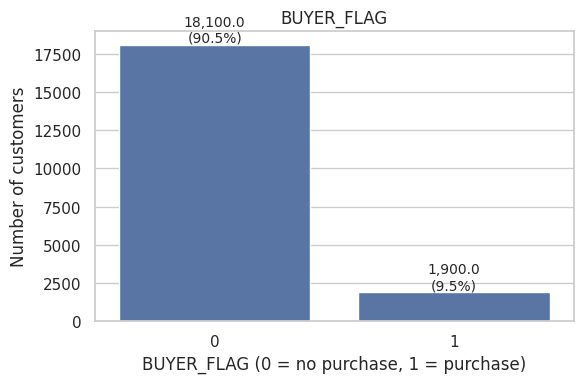

In [ ]:
# --- Class counts and proportions ---
counts = ffp_train['BUYER_FLAG'].value_counts().sort_index()
props  = ffp_train['BUYER_FLAG'].value_counts(normalize=True).sort_index()

summary = pd.DataFrame({'count': counts, 'proportion': props.round(4)})
summary.index = ['0 - Did not buy', '1 - Bought']
print(summary)
print(f"\nImbalance ratio (negatives : positives) = {counts[0] / counts[1]:.1f} : 1")

# --- Visual ---
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='BUYER_FLAG', data=ffp_train, ax=ax)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}\n({p.get_height()/len(ffp_train):.1%})',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.set_title('BUYER_FLAG')
ax.set_xlabel('BUYER_FLAG (0 = no purchase, 1 = purchase)')
ax.set_ylabel('Number of customers')
plt.tight_layout()
plt.show()

The target variable exhibits a distinct class imbalance, with a ratio of approximately 9.5:1 in favor of customers who did not purchase the product (90.5% non-buyers vs. 9.5% buyers).

##Univariate Analysis of Behavioral Features and Binary Flags

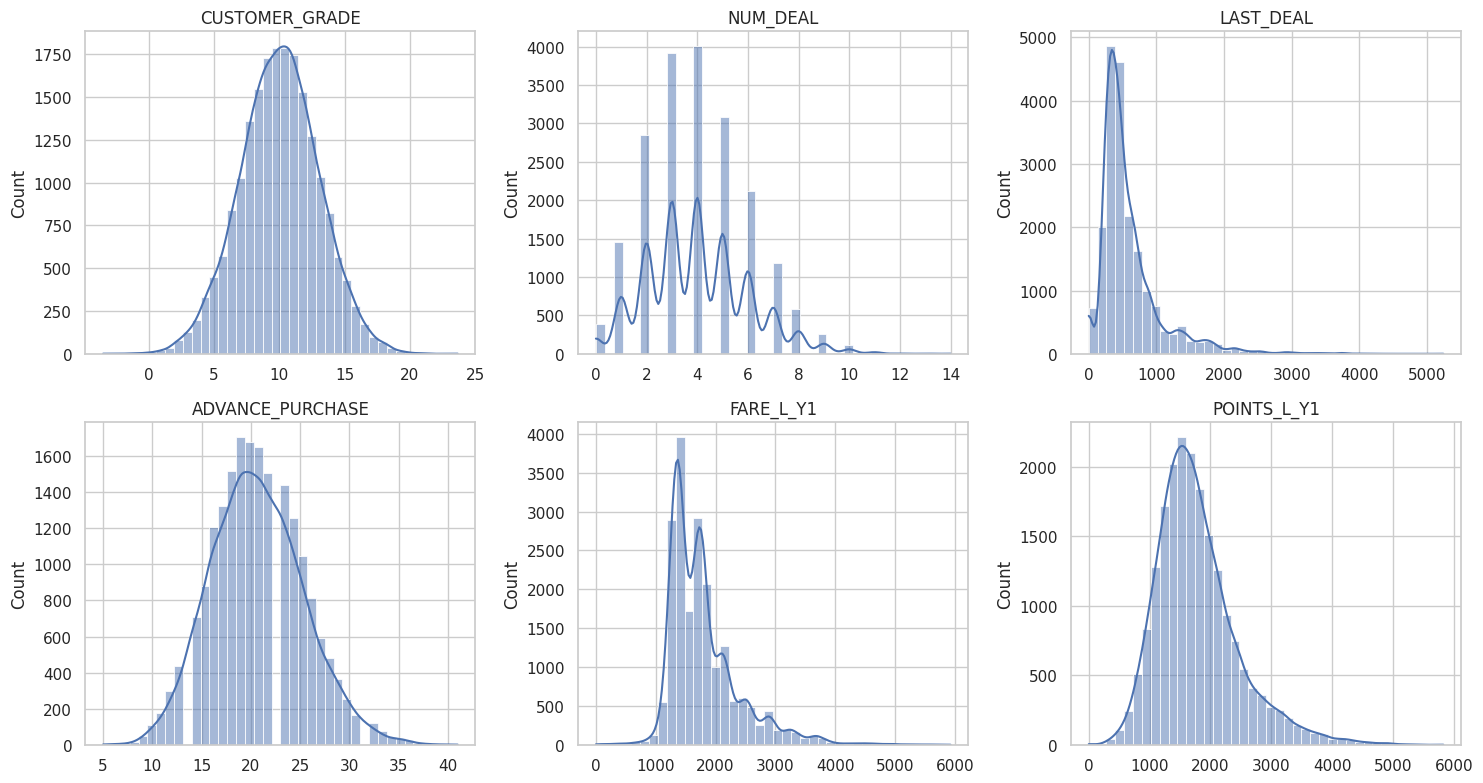

Percentage of customers with a ZERO value, per year:
FARE_L_Y1      0.01 %
FARE_L_Y2      0.02 %
FARE_L_Y3      0.02 %
FARE_L_Y4      0.01 %
FARE_L_Y5      0.01 %
POINTS_L_Y1    0.04 %
POINTS_L_Y2    0.03 %
POINTS_L_Y3    0.02 %
POINTS_L_Y4    0.04 %
POINTS_L_Y5    0.03 %
dtype: object


In [ ]:
# --- Distributions of standalone numeric + one representative year per block ---
num_cols = ['CUSTOMER_GRADE', 'NUM_DEAL', 'LAST_DEAL', 'ADVANCE_PURCHASE',
            'FARE_L_Y1', 'POINTS_L_Y1']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(ffp_train[col], bins=40, kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

# --- How often are FARE / POINTS exactly zero? (inactive-year proxy) ---
fare_cols   = [f'FARE_L_Y{i}'   for i in range(1, 6)]
points_cols = [f'POINTS_L_Y{i}' for i in range(1, 6)]

zero_share = (ffp_train[fare_cols + points_cols] == 0).mean().round(4) * 100
print('Percentage of customers with a ZERO value, per year:')
print(zero_share.astype(str) + ' %')

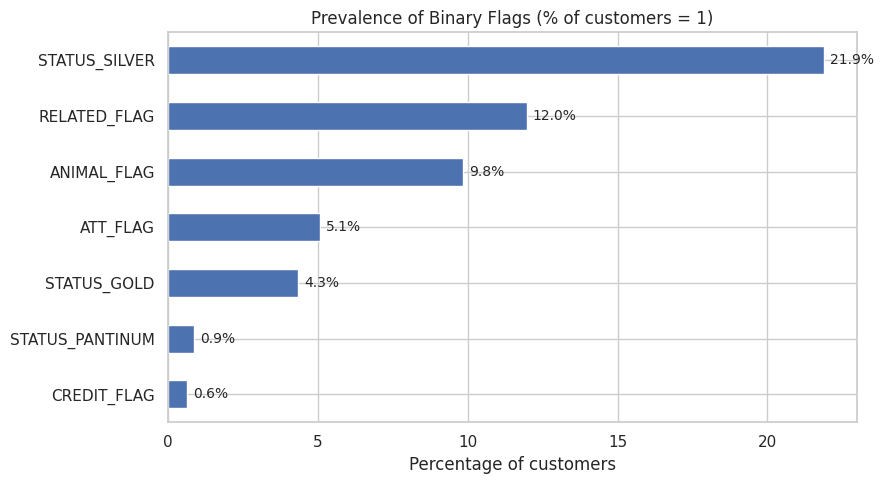

Distribution of how many status tiers each customer holds:
0    14583
1     5417
Name: count, dtype: int64

Customers with NO status tier (base): 72.9%


In [ ]:
flag_cols = ['STATUS_PANTINUM', 'STATUS_GOLD', 'STATUS_SILVER',
             'ATT_FLAG', 'ANIMAL_FLAG', 'CREDIT_FLAG', 'RELATED_FLAG']

# --- Prevalence of each flag (% of customers with value = 1) ---
prevalence = (ffp_train[flag_cols].mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
prevalence.plot(kind='barh', ax=ax)
for i, v in enumerate(prevalence):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=10)
ax.set_title('Prevalence of Binary Flags (% of customers = 1)')
ax.set_xlabel('Percentage of customers')
plt.tight_layout()
plt.show()

# --- Are the loyalty tiers mutually exclusive? ---
status_cols = ['STATUS_PANTINUM', 'STATUS_GOLD', 'STATUS_SILVER']
status_sum = ffp_train[status_cols].sum(axis=1)
print('Distribution of how many status tiers each customer holds:')
print(status_sum.value_counts().sort_index())
print(f"\nCustomers with NO status tier (base): {(status_sum == 0).mean():.1%}")

The proportion of customers with an absolute zero value in their financial expenditure and loyalty points metrics is negligible, remaining consistently between 0.01% and 0.04% across all analyzed years.

The loyalty club membership tiers are strictly mutually exclusive, confirming that each customer belongs to at most one status tier concurrently.

##Bivariate Analysis - Features vs. Target Variable

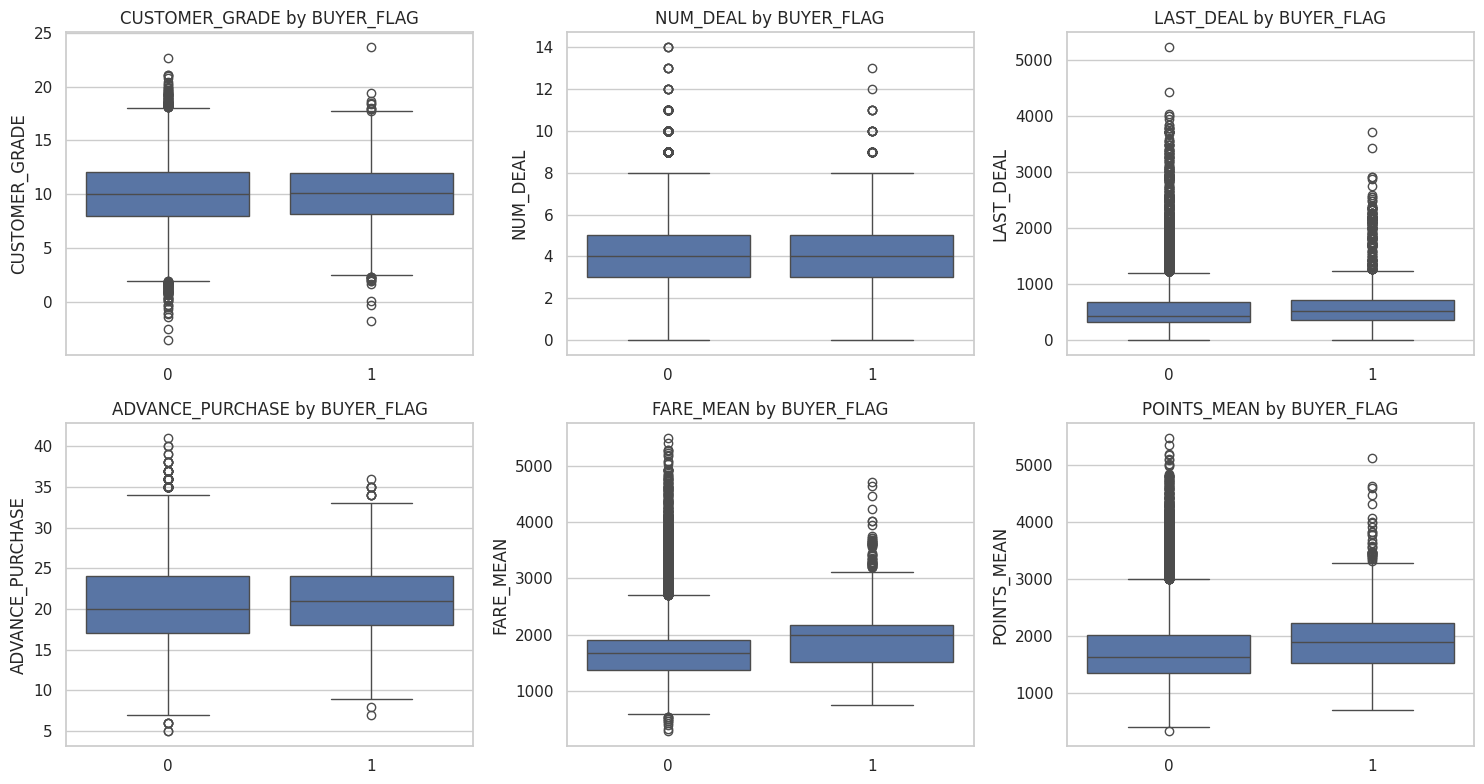

                  mean_non_buyer  mean_buyer  abs_diff  pct_diff
CUSTOMER_GRADE             10.02       10.06      0.05       0.5
NUM_DEAL                    4.01        3.91     -0.10      -2.5
LAST_DEAL                 585.90      648.99     63.09      10.8
ADVANCE_PURCHASE           20.57       21.37      0.80       3.9
FARE_MEAN                1775.63     1929.22    153.59       8.6
POINTS_MEAN              1770.41     1906.30    135.89       7.7


In [ ]:
# --- EDA aggregates for the yearly blocks (exploration only) ---
ffp_train['FARE_MEAN']   = ffp_train[[f'FARE_L_Y{i}'   for i in range(1, 6)]].mean(axis=1)
ffp_train['POINTS_MEAN'] = ffp_train[[f'POINTS_L_Y{i}' for i in range(1, 6)]].mean(axis=1)

bi_num = ['CUSTOMER_GRADE', 'NUM_DEAL', 'LAST_DEAL', 'ADVANCE_PURCHASE',
          'FARE_MEAN', 'POINTS_MEAN']

# --- Boxplots split by target ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, bi_num):
    sns.boxplot(x='BUYER_FLAG', y=col, data=ffp_train, ax=ax)
    ax.set_title(f'{col} by BUYER_FLAG')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

# --- Group means with relative difference ---
grp = ffp_train.groupby('BUYER_FLAG')[bi_num].mean().T
grp.columns = ['mean_non_buyer', 'mean_buyer']
grp['abs_diff'] = (grp['mean_buyer'] - grp['mean_non_buyer'])
grp['pct_diff'] = (grp['abs_diff'] / grp['mean_non_buyer'] * 100).round(1)
print(grp.round(2))

                 buy_rate_if_1  buy_rate_if_0   lift  n_with_flag
flag                                                             
ATT_FLAG                 0.286          0.085  3.376         1013
STATUS_SILVER            0.169          0.074  2.285         4380
RELATED_FLAG             0.134          0.090  1.495         2394
ANIMAL_FLAG              0.097          0.095  1.025         1967
CREDIT_FLAG              0.065          0.095  0.678          124
STATUS_GOLD              0.062          0.096  0.646          866
STATUS_PANTINUM          0.035          0.096  0.367          171


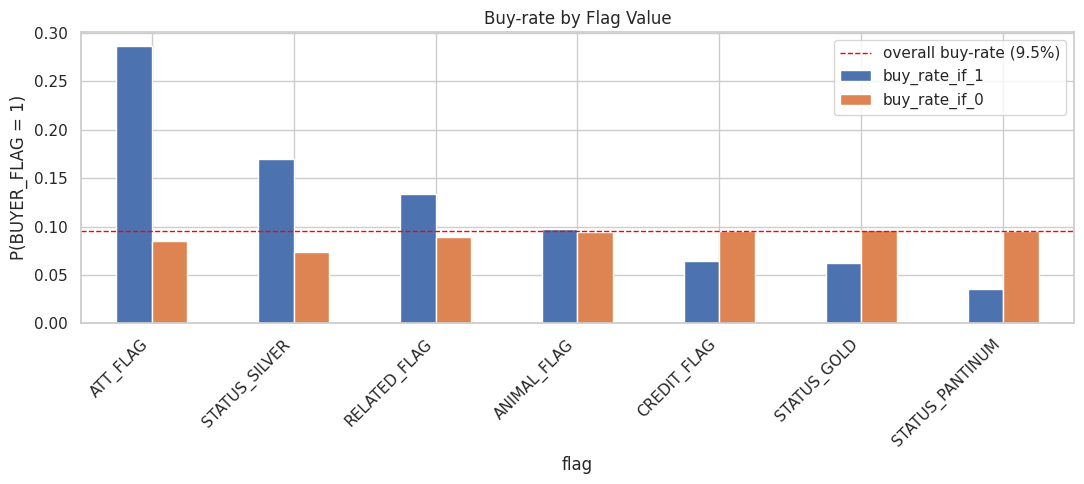

In [ ]:
# --- Buy-rate by flag value, plus lift ---
rows = []
for col in flag_cols:
    rate_1 = ffp_train.loc[ffp_train[col] == 1, 'BUYER_FLAG'].mean()
    rate_0 = ffp_train.loc[ffp_train[col] == 0, 'BUYER_FLAG'].mean()
    rows.append({'flag': col,
                 'buy_rate_if_1': rate_1,
                 'buy_rate_if_0': rate_0,
                 'lift': rate_1 / rate_0,
                 'n_with_flag': int((ffp_train[col] == 1).sum())})

flag_target = pd.DataFrame(rows).set_index('flag').sort_values('lift', ascending=False)
print(flag_target.round(3))

# --- Visual: buy-rate when flag is on vs off ---
plot_df = flag_target[['buy_rate_if_1', 'buy_rate_if_0']].copy()
ax = plot_df.plot(kind='bar', figsize=(11, 5))
ax.axhline(ffp_train['BUYER_FLAG'].mean(), color='red', ls='--', lw=1, label='overall buy-rate (9.5%)')
ax.set_title('Buy-rate by Flag Value')
ax.set_ylabel('P(BUYER_FLAG = 1)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The continuous behavioral metrics, including aggregated expenditure and points, demonstrate high distributional overlap between buyers and non-buyers, indicating a relatively weak direct linear separation.

The categorical indicator flags carry the primary predictive signal. Specifically, the indicator for customer engagement stands out as the single strongest and most dominant predictor among all analyzed flags, yielding the highest conversion lift.

The analysis reveals a non-monotonic relationship within the loyalty tiers, where intermediate-tier members exhibit enhanced purchase rates, whereas top-tier luxury status tiers show a diminished response to the campaign compared to the baseline customer population.

##Correlation Matrix and Multicollinearity Analysis

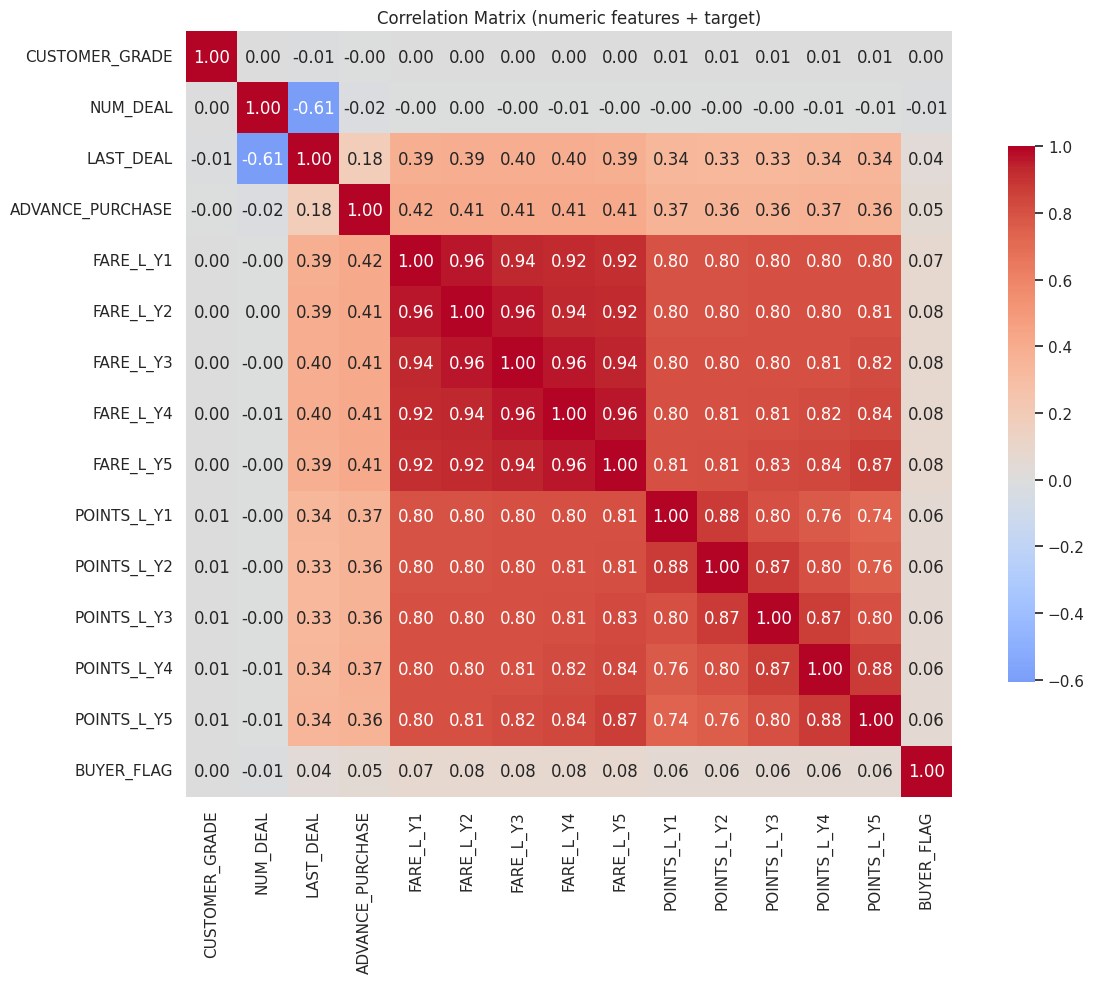

Correlation with BUYER_FLAG (sorted by absolute strength):
ATT_FLAG            0.151
STATUS_SILVER       0.134
FARE_MEAN           0.078
FARE_L_Y5           0.077
FARE_L_Y3           0.077
FARE_L_Y2           0.076
FARE_L_Y4           0.076
FARE_L_Y1           0.075
POINTS_MEAN         0.064
POINTS_L_Y5         0.062
POINTS_L_Y4         0.061
POINTS_L_Y1         0.060
POINTS_L_Y2         0.059
POINTS_L_Y3         0.056
ADVANCE_PURCHASE    0.050
RELATED_FLAG        0.049
LAST_DEAL           0.040
STATUS_GOLD        -0.024
STATUS_PANTINUM    -0.019
NUM_DEAL           -0.015
CREDIT_FLAG        -0.008
CUSTOMER_GRADE      0.004
ANIMAL_FLAG         0.002
Name: BUYER_FLAG, dtype: float64


In [ ]:
corr_cols = (['CUSTOMER_GRADE', 'NUM_DEAL', 'LAST_DEAL', 'ADVANCE_PURCHASE']
             + [f'FARE_L_Y{i}' for i in range(1, 6)]
             + [f'POINTS_L_Y{i}' for i in range(1, 6)]
             + ['BUYER_FLAG'])

corr = ffp_train[corr_cols].corr()

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Correlation Matrix (numeric features + target)')
plt.tight_layout()
plt.show()

# --- Linear association with the target, all numeric + flags, ranked ---
all_num = corr_cols[:-1] + flag_cols + ['FARE_MEAN', 'POINTS_MEAN']
target_corr = ffp_train[all_num + ['BUYER_FLAG']].corr()['BUYER_FLAG'].drop('BUYER_FLAG')
print('Correlation with BUYER_FLAG (sorted by absolute strength):')
print(target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).round(3))

The financial expenditure features exhibit an extremely high correlation ranging from 0.92 to 0.96 among themselves across the analyzed years, with a nearly identical redundant pattern observed within the loyalty points metrics. Introducing all ten raw columns simultaneously into a linear model will introduce severe multicollinearity and degrade predictive stability. Consequently, aggregating these features by engineering a historical average variable is highly recommended prior to the modeling phase.

Irrelevant Feature Identification: The customer grade feature shows virtually no statistical correlation with any other independent variables or with the final purchase outcome, suggesting it can be entirely omitted from the model to eliminate noise.

Weak Linear Separation: All direct linear associations between the independent features and the target purchase decision are remarkably weak, indicating that the underlying patterns are non-linear and would be better captured by tree-based ensemble algorithms.

##summary

Distributions of Continuous Features: The continuous behavioral and financial metrics display nearly identical distributions between buyers and non-buyers, indicating a high degree of overlap and limited direct univariate separating power.

Predictive Value of Indicator Flags: The binary categorical flags carry substantial predictive information. Notably, customers with a specific engagement flag show a strong propensity to purchase, yielding an approximate 3.4-fold conversion lift compared to those without it.

Loyalty Tiers Behavioral Impact: Membership statuses significantly influence customer responsiveness. Due to the observed non-monotonic response patterns across different tiers, these features should be retained and utilized as separate indicator variables in the model.

Feature Engineering and Modeling Strategy: Due to extreme multi-year redundancy, dimensionality reduction through targeted feature engineering (such as calculating historical averages) is required. Given the non-linear relationship of the continuous data and the heavy reliance on categorical indicators, an ensemble tree-based algorithm like Random Forest is highly recommended and expected to perform optimally.

## Next Steps: Data Preparation and Baseline Modeling

Feature Selection and Dropping Irrelevant Attributes: Non-informative and irrelevant features, such as the animal smuggling indicator flag, will be systematically removed from the dataset to reduce unnecessary noise and improve model efficiency.

Recency-Weighted Feature Engineering: To address the severe multi-year redundancy in the financial data, a sophisticated weighted average will be engineered for both the expenditure and loyalty points blocks. Higher statistical weights will be assigned to more recent years (e.g., transactions from one to two years ago) to better capture contemporary customer behavior.

Handling Class Imbalance: Targeted sampling strategies and class-weight adjustment techniques will be implemented during training to mitigate the distinct class imbalance between buyers and non-buyers, ensuring the model does not bias toward the majority class.

Establishing a Tree-Based Baseline: Several ensemble tree-based algorithms will be trained on this prepared dataset to establish a robust baseline performance. From this baseline, iterative feature engineering, parameter tuning, and advanced optimizations will be conducted to enhance predictive performance and maximize business results.